# Inpainting with GPR-LIM

June, 2026

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch
import glob
import sys
sys.path.append('/Users/alliswell48/radio_gpr_work/shao/gprlim')

import gprlim
from gprlim import kernels

from pyuvdata import UVData
import bayeslim as ba

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
sys.path.append('../')
import gp_utils
import importlib
importlib.reload(gp_utils)

<module 'gp_utils' from '/Users/alliswell48/radio_gpr_work/shao/../gp_utils.py'>

In [4]:
import gpytorch
gpytorch.settings.max_cholesky_size._set_value(1_000)

In [5]:
torch.set_default_dtype(torch.float64)
device = 'cpu'

# load the meta-data

The data is of shape (Nbaseline, Ntimes, Nfrequencies, Npolarizations) -> (Nbls, Ntimes, Nfreq, Npol).

The data is complex.

Each "baseline" is formed between two antennas, so a baseline index is often denoted as (ant1, ant2).

Frequencies are in Hz, times are in Julian Date (which is just in days). LST is local sidereal time in radians. Polarization is the polarization state of the electric field, which comes in dual linear polarization state (XX, YY, XY, YX). We also call this (EE, NN, EN, NE) for east and north.

The simulation contains two things:
1. a simulation of the "foregrounds" including the synchrotron emission from the Milky Way galactic disk, and the radio galaxy point source background.

2. a simulation of a mock EoR 21cm field. 

so y = fg + eor for "sum".

The "sum.uvh5" has the two summed together. The "eor.uvh5" has just the EoR simulation. We will generate the noise ourselves in the notebook (using this formalism `hera_cal.noise.predict_noise_variance_from_autos`). 


The simulation has 1600 time integrations and 600 frequency bins, and 243 unique baseline vectors.

We call the data the "visibility" which we also sometimes call the "cross-correlation visibility" i.e. the cross-correlation between two antennas. The visibility of an antenna with itself (e.g. 0, 0) we call the "auto-correlation" visibility.

We observe at MHz frequencies (120 - 190 MHz).

The data are in units of Jansky (Jy).

In [6]:
# load all the data (except for the first 50 integrations which are wrong)
freq_chans = range(0, 600)
time_ints = range(680, 1680)

In [9]:
# specify data
#dfile = '../zen.h6c_idr2_validation.eor.uvh5'
dfile = 'gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5'
#dfile = sorted(glob.glob('../zen.h6c_idr2_validation.24582*.sum.coupled.h5'))

In [10]:
# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=['ee'], time_ints=time_ints, freq_chans=freq_chans,
)
autocorr = vd.data[0,0]

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls'] #当前有的baseline
all_pols = meta['pols']
reds = meta['reds'] #所有list name

# get noise standard deviation
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

In [15]:
red_bls

[(0, 0)]

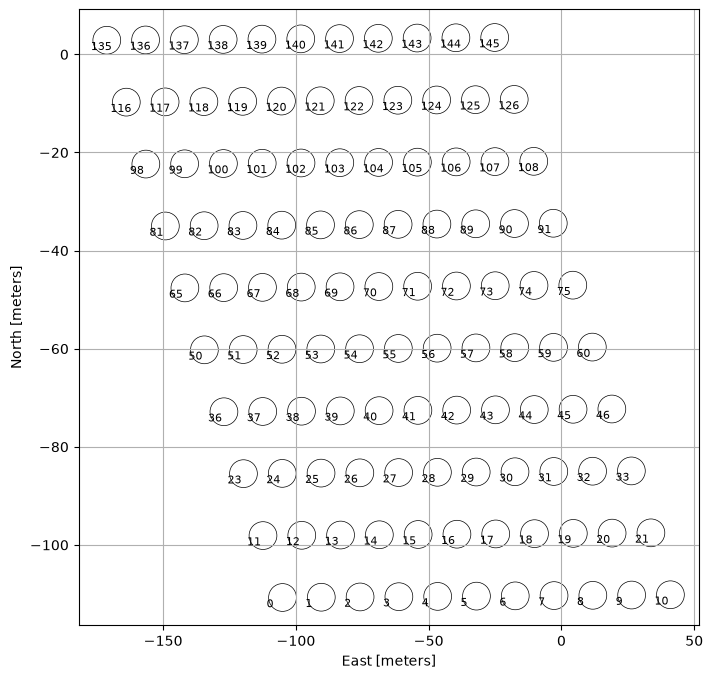

In [11]:
plt.figure(figsize=(8,8))
plt.scatter(*antpos[:, :2].T, fc='none', ec='k', s=400, lw=.5)
for i, a in enumerate(ants):
    plt.text(antpos[i,0]-6, antpos[i,1]-2, a, fontsize=8)
plt.xlabel('East [meters]'); plt.ylabel('North [meters]'); plt.grid();

# load redundant data

load a single redundant baseline

In [19]:
# pick a representative baseline to load and model (start with 0)
bl = (0, 6)

# this gets the index in the redundant set that this baseline falls in
red_ind = np.where([bl in red for red in reds])[0][0]
bls = reds[red_ind][:] #找所有redundant
bl_vec = antp[bls[0][1]] - antp[bls[0][0]]
bl_len = bl_vec.norm()

In [62]:
# load single baseline data
vd, meta = gp_utils.load_uvdata(
    dfile,
    bls=bls,
    time_ints=time_ints,
    freq_chans=freq_chans,
    pols=['ee'],
    device=device,
)
freqs = meta['freqs'] / 1e6
lsts = meta['lsts']
times = (meta['times'] - meta['times'][0]) * 24 * 3600
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']

Antenna pair (1, 7) does not have any data associated with it.
Antenna pair (2, 8) does not have any data associated with it.
Antenna pair (3, 9) does not have any data associated with it.
Antenna pair (4, 10) does not have any data associated with it.
Antenna pair (11, 17) does not have any data associated with it.
Antenna pair (12, 18) does not have any data associated with it.
Antenna pair (13, 19) does not have any data associated with it.
Antenna pair (14, 20) does not have any data associated with it.
Antenna pair (15, 21) does not have any data associated with it.
Antenna pair (23, 29) does not have any data associated with it.
Antenna pair (24, 30) does not have any data associated with it.
Antenna pair (25, 31) does not have any data associated with it.
Antenna pair (26, 32) does not have any data associated with it.
Antenna pair (27, 33) does not have any data associated with it.
Antenna pair (36, 42) does not have any data associated with it.
Antenna pair (37, 43) does not h

In [63]:
inflate_data = False
if inflate_data and vd.Nbls == 1:
    vd = vd.inflate_by_redundancy(bls=reds[red_ind])

In [64]:
add_noise = False
#ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-10
ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-4    #Re(z) ~ N(0, 1/sqrt(2)),Im(z) ~ N(0, 1/sqrt(2))
vd.data += ns_draw

# data: 1e0
# noise,noise_amp * 1e-4 => 1e-4
if add_noise:
    ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-2
    vd.data += ns_draw

In [65]:
# look at how large the data is
print("size of data in MB: {:.1f}".format(vd.data.nbytes/1e6))

size of data in MB: 9.6


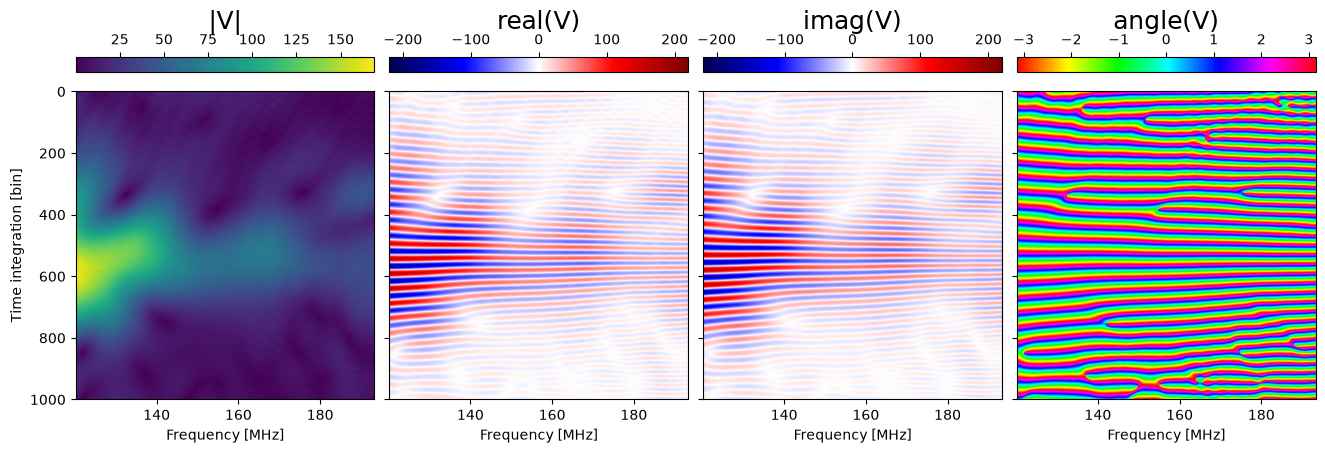

In [66]:
# plot the data (called a waterfall)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)
dstd = vd.data.std()

# visibility amplitude (abs)
cax = axes[0].imshow(vd.data[0,0,0].abs(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_title("|V|", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[0], location='top');
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time integration [bin]');

# visibility real
cax = axes[1].imshow(vd.data[0,0,0].real, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[1].set_title("real(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[1], location='top');
axes[1].set_xlabel('Frequency [MHz]'); axes[1].set_yticklabels([])

# visibility imag
cax = axes[2].imshow(vd.data[0,0,0].imag, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[2].set_title("imag(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[2], location='top');
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_yticklabels([]);

# visibility phase
cax = axes[3].imshow(vd.data[0,0,0].angle(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='hsv')
axes[3].set_title("angle(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[3], location='top');
axes[3].set_xlabel('Frequency [MHz]'); axes[3].set_yticklabels([]);

# define flags

A few different flag types

1. real
2. narrowband full time
3. wideband full time
4. ultraband short time
5. fullband short time
6. narrowband short time
7. narrowband long time
8. wideband long time
9. randn

In [67]:
flag_types = [
    'real',
    #'narrowband_full_time',
    #'wideband_full_time',
    #'ultraband_short_time',
    #'fullband_short_time',
    #'narrowband_short_time',
    #'narrowband_long_time',
    #'wideband_long_time',
    #'randn',
]

flags = torch.zeros((1, Ntimes, Nfreqs), dtype=torch.bool)

if 'real' in flag_types:
    # load flags
    flg = np.load('gpr_data/version2/zen.h6c_idr3.2459951.flag_waterfall_round2.npz')['flags'][time_ints][:, freq_chans, 0]
    flg = torch.as_tensor(flg, device=device)
    flags = flags + flg
    
if 'narrowband_full_time' in flag_types:
    # 1 channel wide, all times
    torch.manual_seed(100)
    N = 40
    rand = torch.randint(low=0, high=Nfreqs, size=(N,))
    flags[:, :, rand] = True
    
if 'wideband_full_time' in flag_types:
    # 10-20 channels wide, all times
    torch.manual_seed(101)
    N = 10
    start = torch.randint(low=0, high=Nfreqs, size=(N,))
    width = torch.randint(low=10, high=20, size=(N,))
    for s, w in zip(start, width):
        flags[:, :, s:s+w] = True

if 'ultraband_short_time' in flag_types:
    # 20-40 wide, 1-4 time integrations
    torch.manual_seed(102)
    N = 10
    start = torch.randint(low=0, high=Nfreqs, size=(N,))
    width = torch.randint(low=20, high=40, size=(N,))
    _time = torch.randint(low=0, high=Ntimes, size=(N,))
    for s, w, t in zip(start, width, _time):
        flags[:, t:t+3, s:s+w] = True

if 'fullband_short_time' in flag_types:
    # all channels wide, 1-3 time integrations
    torch.manual_seed(103)
    N = 20
    rand = torch.randint(low=0, high=Ntimes, size=(N,))
    flags[:, rand] = True

if 'narrowband_short_time' in flag_types:
    # 1-3 channels wide, 3-10 time integrations
    torch.manual_seed(104)
    N = 50
    rand = torch.randint(low=0, high=Nfreqs, size=(N,))
    _time = torch.randint(low=0, high=Ntimes, size=(N,))
    for r, t in zip(rand, _time):
        flags[:, t:t+10, r:r+2] = True
    
if 'narrowband_long_time' in flag_types:
    # 1-3 channels wide, 75 time integrations
    torch.manual_seed(105)
    N = 20
    start = torch.randint(low=0, high=Nfreqs, size=(N,))
    width = torch.randint(low=60, high=80, size=(N,))
    _time = torch.randint(low=0, high=Ntimes, size=(N,))
    for s, w, t in zip(start, width, _time):
        flags[:, t:t+w, s:s+3] = True
    
if 'wideband_long_time' in flag_types:
    # 10-20 channels wide, 20-30 time integrations
    torch.manual_seed(106)
    N = 10
    start = torch.randint(low=0, high=Nfreqs, size=(N,))
    width = torch.randint(low=10, high=20, size=(N,))
    _time = torch.randint(low=0, high=Ntimes, size=(N,))
    for s, w, t in zip(start, width, _time):
        flags[:, t:t+25, s:s+w] = True
    
if 'randn' in flag_types: #从所以flag个位置里面随机抽 500 个。
    rand = np.random.choice(np.arange(flags.numel()), size=500, replace=False)
    flags.ravel()[rand] = True

flagged_times = flags.all(dim=-1, keepdim=True).expand_as(flags)

In [68]:
flags.shape

torch.Size([1, 1000, 600])

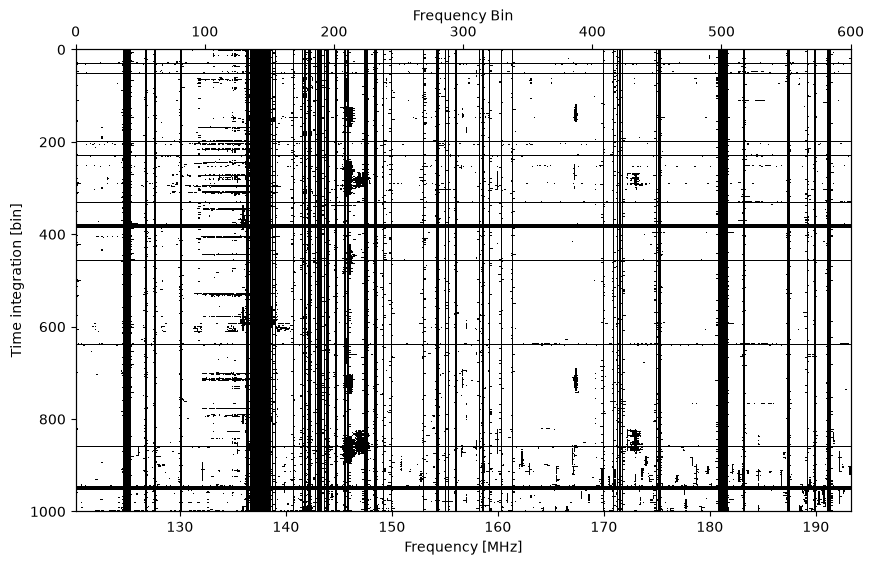

In [69]:
plt.figure(figsize=(10, 6))
plt.imshow(flags[0,:,:],
           cmap='Greys', aspect='auto', interpolation='none', extent=[freqs[0], freqs[-1], Ntimes, 0]
)
plt.xlabel('Frequency [MHz]'); plt.ylabel('Time integration [bin]');
ax2 = plt.twiny(); ax2.set_xlim(0, Nfreqs); ax2.set_xlabel('Frequency Bin');

In [77]:
vd.data.shape

torch.Size([1, 1, 1, 1000, 600])

In [78]:
from bayeslim.fft import FFT

#vd.data: [1, 1, 1, 1000, 600], no baseling;only time,fre
# 1D FT across frequency: V(tau)
FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3) #1e9 Hz-> ns

# 1D FT across time V(fringe)
FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)
# time-> unit 1000 second=> fft ->fringe rate: unit: mHz

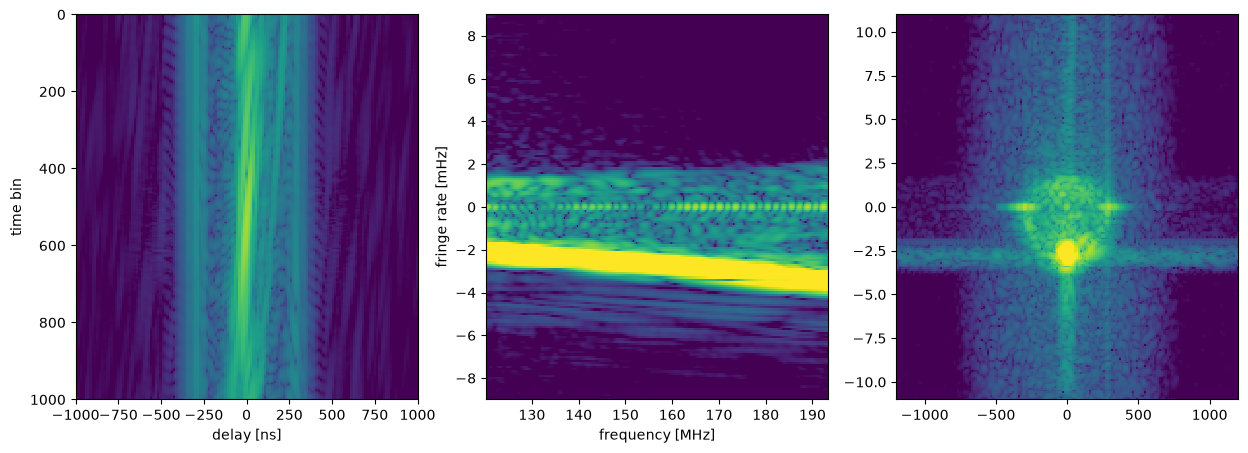

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(FT1(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], Ntimes, 0])
axes[0].set_xlim(-1000, 1000); axes[0].set_xlabel('delay [ns]'); axes[0].set_ylabel('time bin')

axes[1].imshow(FT2(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=0, vmax=3,
               extent=[freqs[0], freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_ylim(-9, 9); axes[1].set_xlabel('frequency [MHz]'); axes[1].set_ylabel('fringe rate [mHz]')

axes[2].imshow(FT1(FT2(vd.data))[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11);

# now do GPR inpainting

Choose a time covariance. A few different modes to select from.

1. A top-hat kernel spanning all fringe-rate modes of the visibility
2. A custom profile

In [80]:
# specify the inpaint method ['2d_1d', '2d', '1d_1d', 'time', 'freq']
inpaint_method = '2d_1d'

In [81]:
# specify the number of time chunks to operate over,时间平均
Ntime_chunks = 200

In [82]:
# generate noise variance
#noise_var = noise_amp.pow(2) * 1e-3
noise_var = noise_amp.pow(2) * 1e-6  # large than simulation noise, (noise_amp * 1e-4)**2, but fine, not to exact match
noise_var[flags] = noise_var.mean() * 1e6

### specify the time and frequency kernel

In [104]:
## Specify kernel parameters

fr_scale = 3e-3  # wide sinc covering all fringe-rate modes, relative to main-lobe
fz_scale = 1e-1  # narrow gaussian covering FR=0 mode, relative to main-lobe
fr_buffer = 1.0  # buffer for sinc kernel mHz

pf_scale = 1e-1  # pitchfork scale, relative to main-lobe
wd_scale = 1e-3  # wide sinc covering all wedge horizon modes
lk_scale = 1e-3  # supra-horizon lekage term
lk_buffer = 150  # leakge buffer [ns]

kernel_var_mult = 3
norm_freq_alpha = -2.0

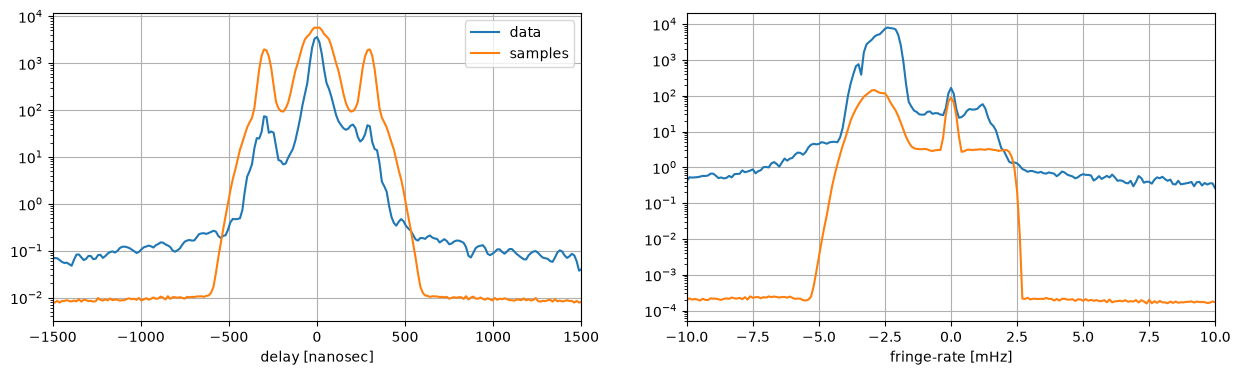

In [105]:
# generate representative kernels and draw from them to confirm realism
time_kernel, freq_kernel = gprlim.pipelines.build_kernels(
    vd.data[0,0]*~flags, noise_var, flags, bl_vec, meta['lat'], times, freqs,
    inpaint=inpaint_method, fr_buffer=fr_buffer, fr_scale=fr_scale, fz_scale=fz_scale,
    pf_scale=pf_scale, wd_scale=wd_scale, lk_scale=lk_scale, lk_buffer=lk_buffer,
    kernel_var_mult=kernel_var_mult, norm_freq_alpha=norm_freq_alpha, parameter=False,
)   #？？？？ fit了吗

# draw 1D samples each
samples = gprlim.models.prior_draws_1d(freq_kernel, freqs, size=100, jitter=1e-10)[None]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(FT1.freqs, FT1(vd.data)[0,0,0].abs().mean(0), label='data')
axes[0].plot(FT1.freqs, FT1(samples).abs().mean((0,1)), label='samples');
axes[0].set_xlim(-1500, 1500); axes[0].set_xlabel('delay [nanosec]'); axes[0].legend(); axes[0].set_yscale('log');
axes[0].grid()

samples = gprlim.models.prior_draws_1d(time_kernel, times, size=100, jitter=1e-10)[...,None]

axes[1].plot(FT2.freqs, FT2(vd.data)[0,0,0].abs().mean(1), label='data')
axes[1].plot(FT2.freqs, FT2(samples).abs().mean((0,2)), label='samples');
axes[1].set_xlim(-10, 10); axes[1].set_xlabel('fringe-rate [mHz]'); axes[0].legend(); axes[1].set_yscale('log');
axes[1].grid()

# now do the inpainting

Iterate over Ntime_chunks at a time, then concat results.

In [106]:
vd.data.shape

torch.Size([1, 1, 1, 1000, 600])

In [108]:
vd.data[0, 0, :, chunks].shape

torch.Size([1, 200, 600])

In [114]:
%%time
vd_inp, vd_mdl = [], []
for chunks in ba.utils.split_into_groups(np.arange(Ntimes), Nelem=Ntime_chunks):

    inp_y, mdl = gprlim.pipelines.hera_inpaint(
        vd.data[0, 0, :, chunks] * ~flags[:, chunks],   #[1, 1, 1, 1000, 600]-> [1, 200, 600]
        noise_var[:, chunks],
        flags[:, chunks],
        bl_vec,
        meta['lat'],
        times[chunks],
        freqs,
        norm_freq_alpha=norm_freq_alpha,
        inpaint=inpaint_method,
        flag_Ntimes=1000,
        fr_scale=fr_scale,
        fz_scale=fz_scale,
        fr_buffer=fr_buffer,
        pf_scale=pf_scale,
        wd_scale=wd_scale,
        lk_scale=lk_scale,
        lk_buffer=lk_buffer,
        kernel_var_mult=kernel_var_mult,
        noise_mult=100,
        precond_2d='sparse_blockdiag',
        red_avg_2d=True,
        n_threads=16,
    )

    # store the inpainted data
    _vd_inp = vd.select(time_inds=chunks, inplace=False)
    _vd_inp.data = inp_y[None, None]
    vd_inp.append(_vd_inp)
    _vd_mdl = vd.select(time_inds=chunks, inplace=False)
    _vd_mdl.data = mdl.expand(inp_y.shape)[None, None]
    vd_mdl.append(_vd_mdl)
    

vd_inp = ba.dataset.concat_VisData(vd_inp, 'time')
vd_mdl = ba.dataset.concat_VisData(vd_mdl, 'time')

[<bayeslim.dataset.VisData object at 0x12fe979d0>, <bayeslim.dataset.VisData object at 0x12ff18210>, <bayeslim.dataset.VisData object at 0x12fedaf50>, <bayeslim.dataset.VisData object at 0x12f258350>, <bayeslim.dataset.VisData object at 0x1328f5390>]
CPU times: user 21 s, sys: 1.93 s, total: 23 s
Wall time: 6.02 s


# now average the data and plot

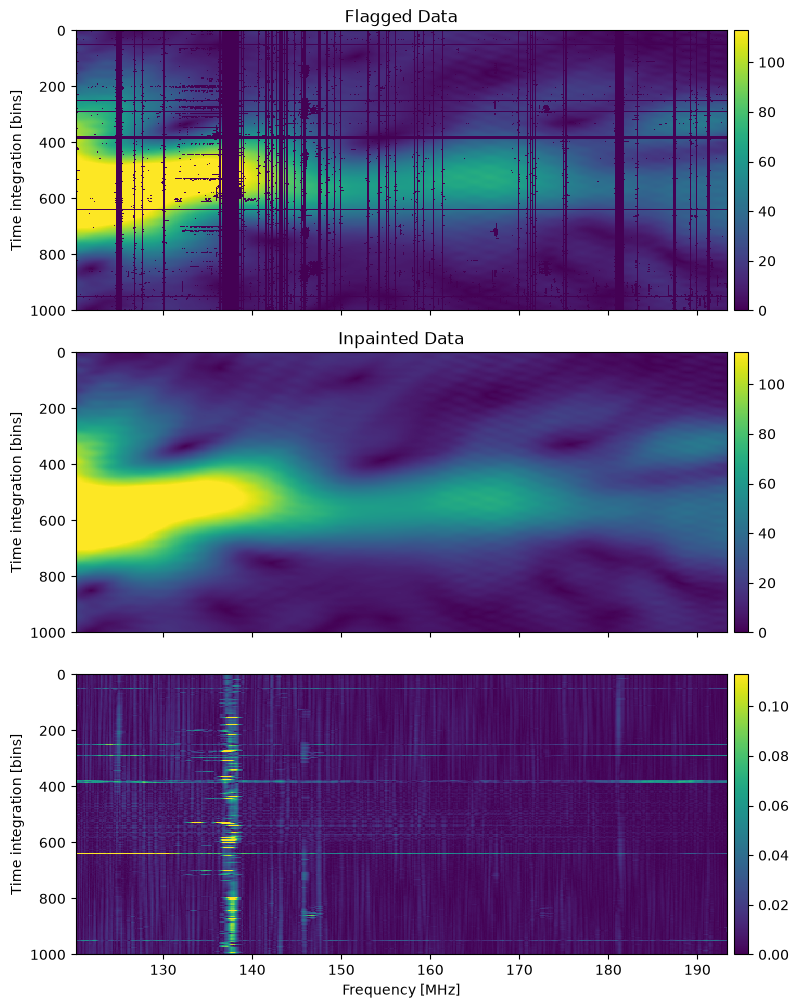

In [116]:
# plot the single baseline inpainted solution
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=.15)
dmax = vd.data[0,0,0].abs().max()/1.5

cax = axes[0].imshow((vd.data[0,0,0]*~flags[0]).abs(), aspect='auto', interpolation='none', vmin=0, vmax=dmax,
               extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_xticklabels([]); axes[0].set_ylabel('Time integration [bins]')
axes[0].set_title('Flagged Data')
fig.colorbar(cax, ax=axes[0], pad=.01)

cax = axes[1].imshow(vd_inp.data[0,0,0].abs(), aspect='auto', interpolation='none', vmin=0, vmax=dmax,
               extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[1].set_xticklabels([]); axes[1].set_ylabel('Time integration [bins]')
axes[1].set_title('Inpainted Data')
fig.colorbar(cax, ax=axes[1], pad=.01)

cax = axes[2].imshow((vd.data[0,0,0]-vd_mdl.data[0,0,0]).abs(), aspect='auto', interpolation='none',
                     vmin=0, vmax=dmax/1000, extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_ylabel('Time integration [bins]')
fig.colorbar(cax, ax=axes[2], pad=.01);

Text(0.5, 0, 'Time [JD]')

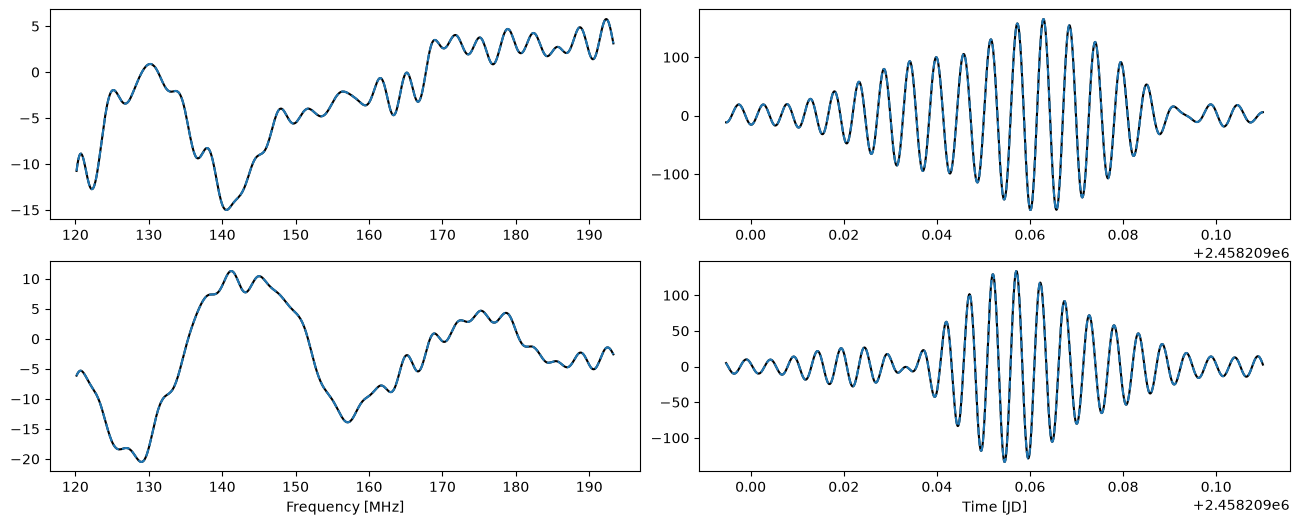

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6)); fig.subplots_adjust(wspace=.1)
#[1, 1, 1, 1000, 600]
axes[0,0].plot(freqs,     vd.data[0,0,0,5].real, c='k')  
axes[0,0].plot(freqs, vd_inp.data[0,0,0,5].real, ls='--')
axes[1,0].plot(freqs,     vd.data[0,0,0,100].real, c='k')
axes[1,0].plot(freqs, vd_inp.data[0,0,0,100].real, ls='--')
axes[0,1].plot(vd.times,     vd.data[0,0,0,:,5].real, c='k')
axes[0,1].plot(vd.times, vd_inp.data[0,0,0,:,5].real, ls='--')
axes[1,1].plot(vd.times,     vd.data[0,0,0,:,100].real, c='k')
axes[1,1].plot(vd.times, vd_inp.data[0,0,0,:,100].real, ls='--');
axes[1,0].set_xlabel('Frequency [MHz]'); axes[1,1].set_xlabel('Time [JD]')

In [118]:
# coherent time average the data
avg_times = ba.utils.split_into_groups(torch.arange(Ntimes), Nelem=20)
time_wgts = 1/(flagged_times*1e5 + 1e0)

vd_avg = vd.time_average(avg_times, wgts=time_wgts, rephase=True, inplace=False)

vd_flg = vd * ~flags
vd_flg_avg = vd_flg.time_average(avg_times, wgts=time_wgts, rephase=True, inplace=False)

vd_inp_avg = vd_inp.time_average(avg_times, wgts=time_wgts, rephase=True, inplace=False)

vd_ns = vd.copy(copydata=True)
vd_ns.data = ns_draw
vd_ns_avg = vd_ns.time_average(avg_times, wgts=time_wgts, rephase=True, inplace=False)

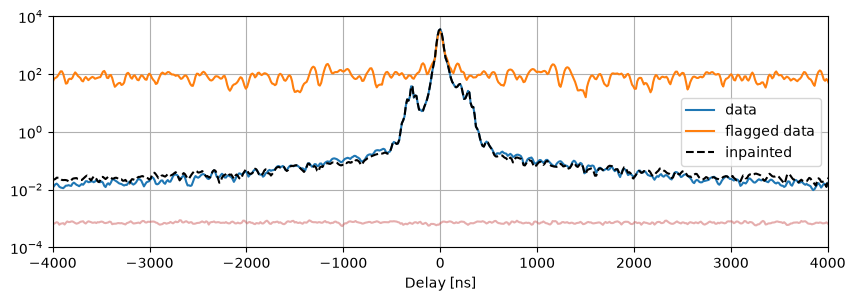

In [121]:
plt.figure(figsize=(10, 3))
plt.plot(FT1.freqs,  FT1(vd_avg.data[0,0].mean(0))[:].abs().mean(0), label='data')
plt.plot(FT1.freqs,  FT1(vd_flg_avg.data[0,0].mean(0))[:].abs().mean(0), label='flagged data')
plt.plot(FT1.freqs,  FT1(vd_inp_avg.data[0,0].mean(0))[:].abs().mean(0), c='k', ls='--', label='inpainted')
plt.plot(FT1.freqs,  FT1(vd_ns_avg.data[0,0].mean(0))[:].abs().mean(0), c='indianred', ls='-', alpha=.5)
plt.yscale('log'); plt.grid(); plt.xlim(-4000, 4000); plt.ylim(1e-4, 1e4); plt.legend()
plt.xlabel('Delay [ns]');

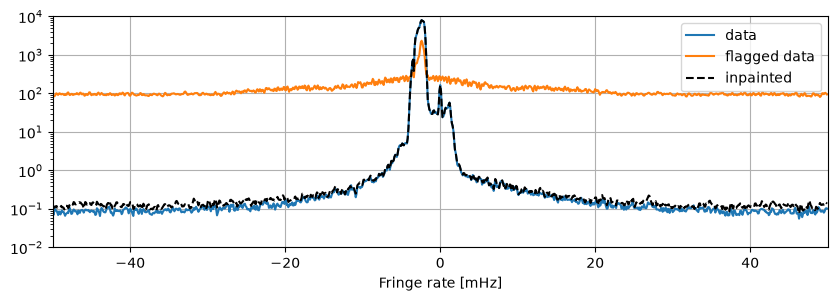

In [125]:
plt.figure(figsize=(10, 3))
plt.plot(FT2.freqs,  FT2(vd.data[0,0].mean(0))[:].abs().mean(1), label='data')
plt.plot(FT2.freqs,  FT2((flags*vd.data[0,0]).mean(0))[:].abs().mean(1), label='flagged data')
plt.plot(FT2.freqs,  FT2(vd_inp.data[0,0].mean(0))[:].abs().mean(1), c='k', ls='--', label='inpainted')
plt.yscale('log'); plt.grid(); plt.xlim(-50, 50); plt.ylim(1e-2, 1e4); plt.legend()
plt.xlabel('Fringe rate [mHz]');

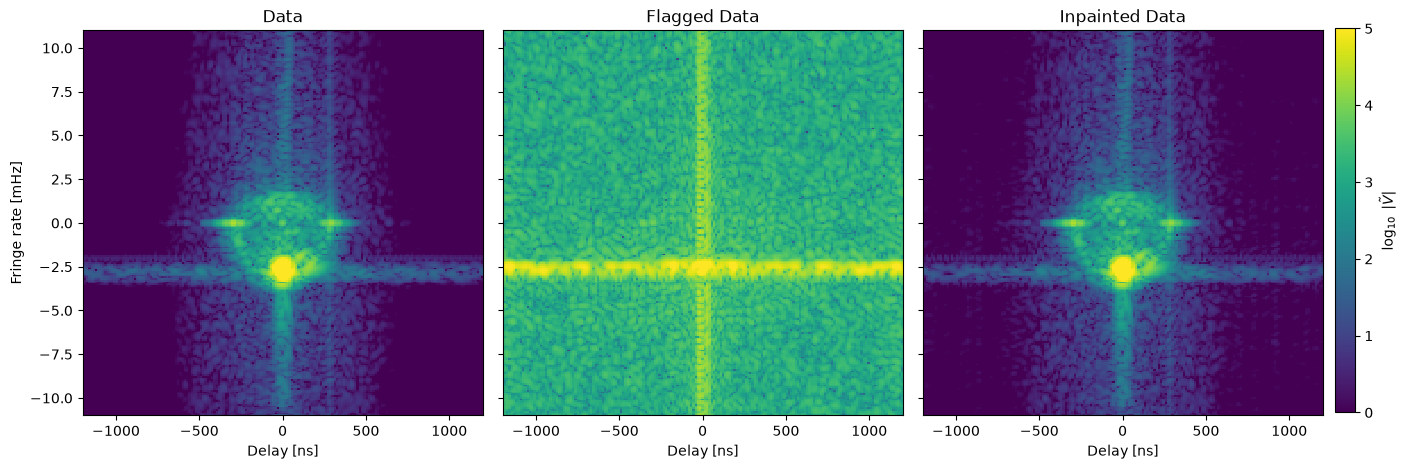

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)

axes[0].imshow(FT1(FT2(vd.data[0,0].mean(0))).abs().log10(), aspect='auto', interpolation='none',
               vmin=0, vmax=5, extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[0].set_xlim(-1200, 1200); axes[0].set_ylim(-11, 11); axes[0].set_title('Data')
axes[0].set_xlabel('Delay [ns]'); axes[0].set_ylabel('Fringe rate [mHz]')

axes[1].imshow(FT1(FT2((flags*vd.data[0,0]).mean(0))).abs().log10(), aspect='auto', interpolation='none',
               vmin=0, vmax=5, extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_xlim(-1200, 1200); axes[1].set_ylim(-11, 11); axes[1].set_title('Flagged Data')
axes[1].set_xlabel('Delay [ns]'); axes[1].set_yticklabels([]);

cax = axes[2].imshow(FT1(FT2(vd_inp.data[0,0].mean(0))).abs().log10(), aspect='auto', interpolation='none',
               vmin=0, vmax=5, extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11); axes[2].set_title('Inpainted Data')
axes[2].set_xlabel('Delay [ns]'); axes[2].set_yticklabels([]);

cbax = fig.add_axes([0.84, 0.1, .08, .8]); cbax.axis('off')
cbar = fig.colorbar(cax, ax=cbax); cbar.set_label(r'$\log_{10}\ |\tilde{V}|$')

# plot other metrics?

Like the average delay spectrum power for |delay| > 1000 ns?


# 1. amplitude and residual

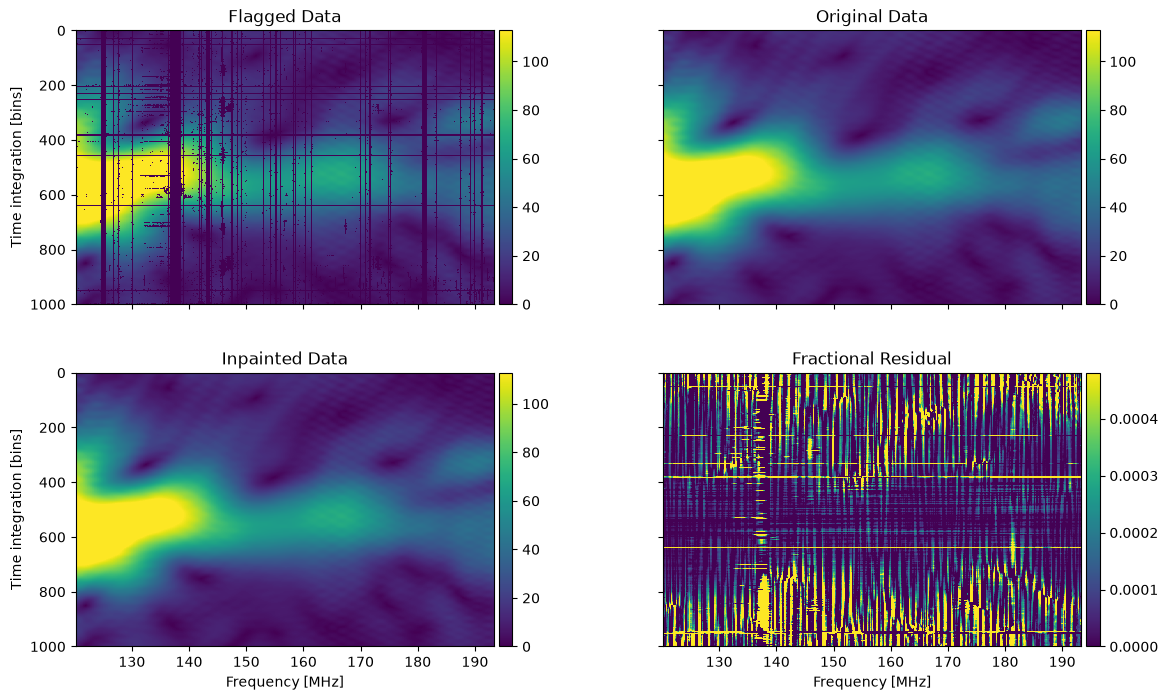

In [162]:
# Plot the single-baseline inpainted solution
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.subplots_adjust(hspace=0.25, wspace=0.18)

dmax = vd.data[0, 0, 0].abs().max() / 1.5

# --------------------------------------------------
# Top left: flagged data
# --------------------------------------------------
cax = axes[0, 0].imshow(
    (vd.data[0, 0, 0] * ~flags[0]).abs(),
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=dmax,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[0, 0].set_title("Flagged Data")
axes[0, 0].set_ylabel("Time integration [bins]")
axes[0, 0].set_xticklabels([])
fig.colorbar(cax, ax=axes[0, 0], pad=0.01)

# --------------------------------------------------
# Top right: true / unflagged data
# --------------------------------------------------
cax = axes[0, 1].imshow(
    vd.data[0, 0, 0].abs(),
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=dmax,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[0, 1].set_title("Original Data")
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])
fig.colorbar(cax, ax=axes[0, 1], pad=0.01)

# --------------------------------------------------
# Bottom left: inpainted data
# --------------------------------------------------
cax = axes[1, 0].imshow(
    vd_inp.data[0, 0, 0].abs(),
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=dmax,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[1, 0].set_title("Inpainted Data")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Time integration [bins]")
fig.colorbar(cax, ax=axes[1, 0], pad=0.01)

# --------------------------------------------------
# Bottom right: fractional residual
# --------------------------------------------------
frac_resid = ((vd.data[0, 0, 0].abs() - vd_mdl.data[0, 0, 0].abs()) / vd.data[0, 0, 0].abs())

cax = axes[1, 1].imshow(
    frac_resid,
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=torch.max(frac_resid)/1000,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[1, 1].set_title("Fractional Residual")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_yticklabels([])
fig.colorbar(cax, ax=axes[1, 1], pad=0.01)

plt.show()

# 2.1 Phase and absolute residual phase error
##    time bins (680, 1680), frequency channels (0, 600)

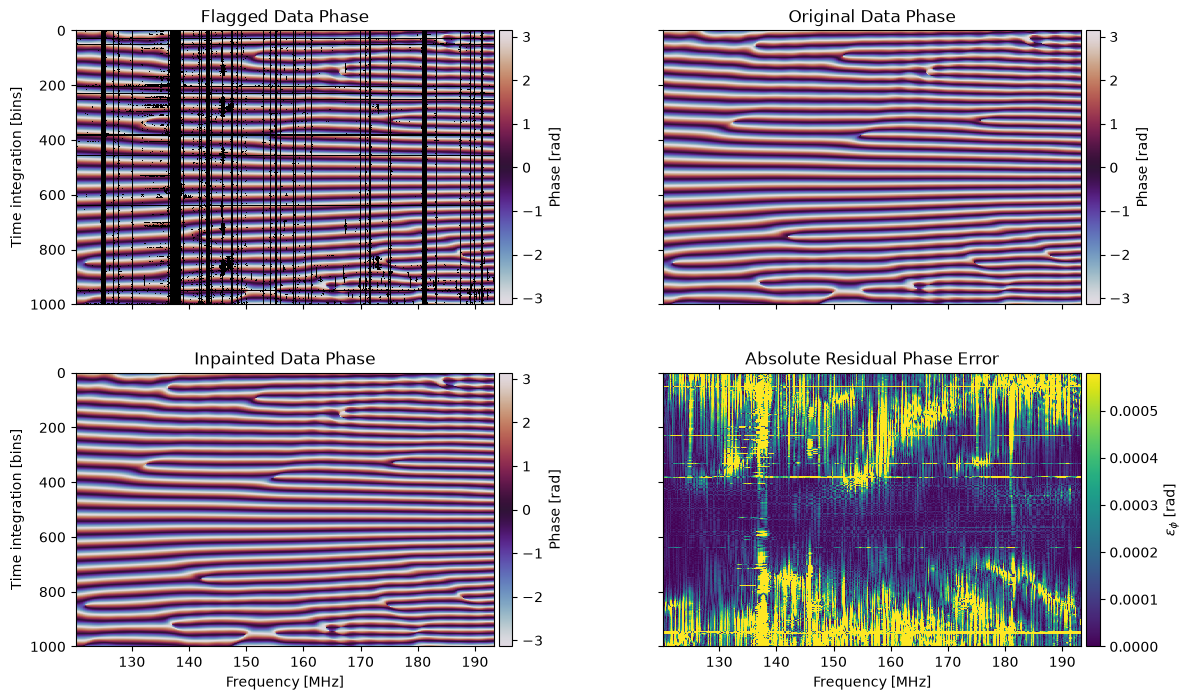

In [200]:
# Plot the single-baseline inpainted solution in phase
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.subplots_adjust(hspace=0.25, wspace=0.18)

phase_vmin = -np.pi
phase_vmax = np.pi

# Colormap: show flagged / NaN pixels as black
phase_cmap = plt.get_cmap("twilight").copy()
phase_cmap.set_bad(color="black")

resid_cmap = plt.get_cmap("viridis").copy()
resid_cmap.set_bad(color="black")

# --------------------------------------------------
# Top left: flagged data phase
# --------------------------------------------------
flagged_data = vd.data[0, 0, 0]
flag_mask = flags[0]

flagged_phase = torch.angle(flagged_data).clone()
flagged_phase[flag_mask] = torch.nan

cax = axes[0, 0].imshow(
    flagged_phase,
    aspect="auto",
    interpolation="none",
    vmin=phase_vmin,
    vmax=phase_vmax,
    cmap=phase_cmap,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[0, 0].set_title("Flagged Data Phase")
axes[0, 0].set_ylabel("Time integration [bins]")
axes[0, 0].set_xticklabels([])
fig.colorbar(cax, ax=axes[0, 0], pad=0.01, label="Phase [rad]")

# --------------------------------------------------
# Top right: original data phase
# --------------------------------------------------
cax = axes[0, 1].imshow(
    torch.angle(vd.data[0, 0, 0]),
    aspect="auto",
    interpolation="none",
    vmin=phase_vmin,
    vmax=phase_vmax,
    cmap=phase_cmap,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[0, 1].set_title("Original Data Phase")
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])
fig.colorbar(cax, ax=axes[0, 1], pad=0.01, label="Phase [rad]")

# --------------------------------------------------
# Bottom left: inpainted data phase
# --------------------------------------------------
cax = axes[1, 0].imshow(
    torch.angle(vd_inp.data[0, 0, 0]),
    aspect="auto",
    interpolation="none",
    vmin=phase_vmin,
    vmax=phase_vmax,
    cmap=phase_cmap,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[1, 0].set_title("Inpainted Data Phase")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Time integration [bins]")
fig.colorbar(cax, ax=axes[1, 0], pad=0.01, label="Phase [rad]")

# --------------------------------------------------
# Bottom right: absolute residual phase error
# --------------------------------------------------
phase_true = torch.angle(vd.data[0, 0, 0])
phase_model = torch.angle(vd_mdl.data[0, 0, 0])

# Raw absolute phase difference
dphi = torch.abs(phase_model - phase_true)

# Absolute residual phase error:
# epsilon_phi = min(|2pi - dphi|, dphi)
phase_resid = torch.minimum(
    torch.abs(2 * torch.pi - dphi),
    dphi,
)

# Mask originally flagged pixels in residual plot
phase_resid_plot = phase_resid.clone()


cax = axes[1, 1].imshow(
    phase_resid_plot,
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=torch.max(phase_resid_plot) / 1000,
    cmap=resid_cmap,
    extent=[freqs[0], freqs[-1], Ntimes, 0],
)

axes[1, 1].set_title("Absolute Residual Phase Error")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_yticklabels([])
fig.colorbar(cax, ax=axes[1, 1], pad=0.01, label=r"$\epsilon_\phi$ [rad]")

plt.show()

# 2.1 Phase and absolute residual phase error
##    time bins (0, 100), frequency channels (0, 250)

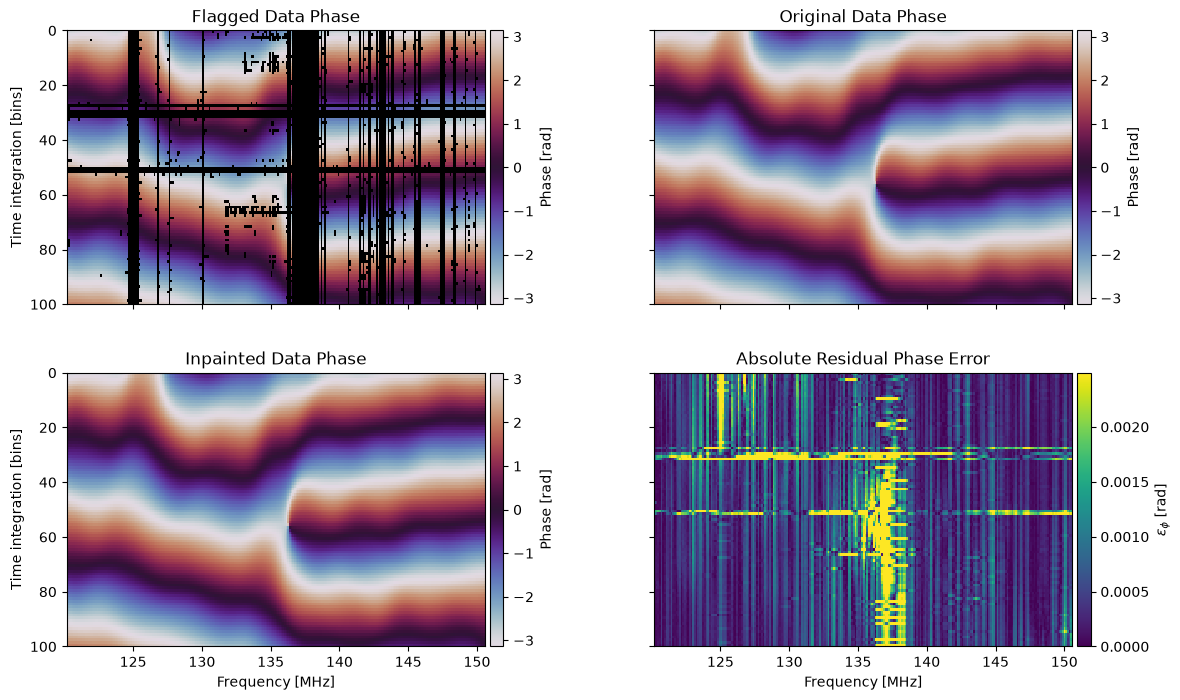

In [198]:
# Plot the single-baseline inpainted solution in phase
# Only show time bins 0:100 and frequency channels 0:250
#phase: 0~2pi 

t_slice = slice(0, 100)
f_slice = slice(0, 250)

freqs_plot = freqs[f_slice]
Ntimes_plot = 100

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.subplots_adjust(hspace=0.25, wspace=0.18)

phase_vmin = -np.pi
phase_vmax = np.pi

# Colormap: use black for NaN / masked values
phase_cmap = plt.get_cmap("twilight").copy()
phase_cmap.set_bad(color="black")

resid_cmap = plt.get_cmap("viridis").copy()
resid_cmap.set_bad(color="black")

# --------------------------------------------------
# Top left: flagged data phase
# --------------------------------------------------
flagged_data = vd.data[0, 0, 0, t_slice, f_slice]
flag_mask = flags[0, t_slice, f_slice]

flagged_phase = torch.angle(flagged_data).clone()
flagged_phase[flag_mask] = torch.nan

cax = axes[0, 0].imshow(
    flagged_phase,
    aspect="auto",
    interpolation="none",
    vmin=phase_vmin,
    vmax=phase_vmax,
    cmap=phase_cmap,
    extent=[freqs_plot[0], freqs_plot[-1], Ntimes_plot, 0],
)

axes[0, 0].set_title("Flagged Data Phase")
axes[0, 0].set_ylabel("Time integration [bins]")
axes[0, 0].set_xticklabels([])
fig.colorbar(cax, ax=axes[0, 0], pad=0.01, label="Phase [rad]")

# --------------------------------------------------
# Top right: original data phase
# --------------------------------------------------
cax = axes[0, 1].imshow(
    torch.angle(vd.data[0, 0, 0, t_slice, f_slice]),
    aspect="auto",
    interpolation="none",
    vmin=phase_vmin,
    vmax=phase_vmax,
    cmap=phase_cmap,
    extent=[freqs_plot[0], freqs_plot[-1], Ntimes_plot, 0],
)

axes[0, 1].set_title("Original Data Phase")
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])
fig.colorbar(cax, ax=axes[0, 1], pad=0.01, label="Phase [rad]")

# --------------------------------------------------
# Bottom left: inpainted data phase
# --------------------------------------------------
cax = axes[1, 0].imshow(
    torch.angle(vd_inp.data[0, 0, 0, t_slice, f_slice]),
    aspect="auto",
    interpolation="none",
    vmin=phase_vmin,
    vmax=phase_vmax,
    cmap=phase_cmap,
    extent=[freqs_plot[0], freqs_plot[-1], Ntimes_plot, 0],
)

axes[1, 0].set_title("Inpainted Data Phase")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Time integration [bins]")
fig.colorbar(cax, ax=axes[1, 0], pad=0.01, label="Phase [rad]")

# --------------------------------------------------
# Bottom right: absolute residual phase error
# --------------------------------------------------
phase_true = torch.angle(vd.data[0, 0, 0, t_slice, f_slice])
phase_model = torch.angle(vd_mdl.data[0, 0, 0, t_slice, f_slice])

dphi = torch.abs(phase_model - phase_true)

phase_resid = torch.minimum(
    torch.abs(2 * torch.pi - dphi),
    dphi,
)

# Optional: mask originally flagged pixels in residual plot too
phase_resid_plot = phase_resid.clone()


cax = axes[1, 1].imshow(
    phase_resid_plot,
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=torch.max(phase_resid_plot) / 10,
    cmap=resid_cmap,
    extent=[freqs_plot[0], freqs_plot[-1], Ntimes_plot, 0],
)

axes[1, 1].set_title("Absolute Residual Phase Error")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_yticklabels([])
fig.colorbar(cax, ax=axes[1, 1], pad=0.01, label=r"$\epsilon_\phi$ [rad]")

plt.show()

# 3. Residual distributions: 
## a) Fractional amplitude residual
## b) Absolute amplitude residual
## c) Absolute residual phase error

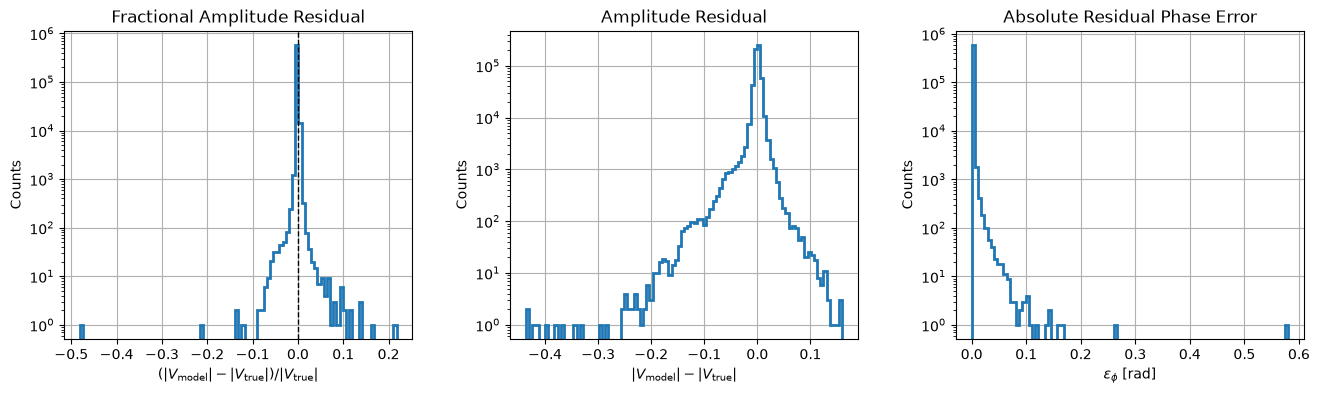

In [311]:
# ==================================================
# Residual distributions: absolute, fractional, and phase residuals
# ==================================================

true_amp = vd.data[0, 0, 0].abs()
model_amp = vd_mdl.data[0, 0, 0].abs()



# --------------------------------------------------
# 1. Fractional amplitude residual
#    (|V_model| - |V_true|) / |V_true|
# --------------------------------------------------
frac_resid = (model_amp - true_amp) / true_amp

# --------------------------------------------------
# 2. Absolute amplitude residual
#    | |V_model| - |V_true| |
# --------------------------------------------------
abs_resid = model_amp - true_amp


# --------------------------------------------------
# 3. Absolute residual phase error
#    epsilon_phi = min(|2pi - |phi_model - phi_true||, |phi_model - phi_true|)
# --------------------------------------------------
phase_true = torch.angle(vd.data[0, 0, 0])
phase_model = torch.angle(vd_mdl.data[0, 0, 0])

dphi = torch.abs(phase_model - phase_true)

phase_resid = torch.minimum(
    torch.abs(2 * torch.pi - dphi ),
    dphi,
)

# --------------------------------------------------
# Flatten and remove NaN / inf values
# --------------------------------------------------
abs_resid_1d = abs_resid.flatten()
frac_resid_1d = frac_resid.flatten()
phase_resid_1d = phase_resid.flatten()

abs_resid_1d = abs_resid_1d[torch.isfinite(abs_resid_1d)]
frac_resid_1d = frac_resid_1d[torch.isfinite(frac_resid_1d)]
phase_resid_1d = phase_resid_1d[torch.isfinite(phase_resid_1d)]


# ==================================================
# Plot distributions
# ==================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.subplots_adjust(wspace=0.28)



# --------------------------------------------------
# Fractional amplitude residual distribution
# --------------------------------------------------
axes[0].hist(
    frac_resid_1d.detach().cpu().numpy(),
    bins=100,
    histtype="step",
    linewidth=2,
)

axes[0].axvline(0, color="k", linestyle="--", linewidth=1)
axes[0].set_title("Fractional Amplitude Residual")
axes[0].set_xlabel(r"$(|V_{\rm model}| - |V_{\rm true}|) / |V_{\rm true}|$")
axes[0].set_ylabel("Counts")
axes[0].set_yscale("log")
axes[0].grid()


# --------------------------------------------------
# Amplitude residual distribution
# --------------------------------------------------
axes[1].hist(
    abs_resid_1d.detach().cpu().numpy(),
    bins=100,
    histtype="step",
    linewidth=2,
)

axes[1].set_title("Amplitude Residual")
axes[1].set_xlabel(r"$|V_{\rm model}| - |V_{\rm true}|$")
axes[1].set_ylabel("Counts")
axes[1].set_yscale("log")
axes[1].grid()


# --------------------------------------------------
# Phase residual distribution
# --------------------------------------------------
axes[2].hist(
    phase_resid_1d.detach().cpu().numpy(),
    bins=100,
    histtype="step",
    linewidth=2,
)

axes[2].set_title("Absolute Residual Phase Error")
axes[2].set_xlabel(r"$\epsilon_\phi$ [rad]")
axes[2].set_ylabel("Counts")
axes[2].set_yscale("log")
axes[2].grid()

plt.show()

In [314]:
# ==================================================
# Mean and 1-sigma uncertainty of fractional residual [%]
# ==================================================

frac_mean_percent = frac_resid_1d.mean() * 100
frac_std_percent = frac_resid_1d.std(unbiased=True) * 100

print(f"Mean fractional amplitude residual = {frac_mean_percent:.4f}%")
print(f"1-sigma scatter          = {frac_std_percent:.4f}%")
print(f"Mean ± 1σ                = {frac_mean_percent:.4f}% ± {frac_std_percent:.4f}%")

Mean fractional amplitude residual = -0.0032%
1-sigma scatter          = 0.1680%
Mean ± 1σ                = -0.0032% ± 0.1680%


# 4.1 Frequency-space averaged |V|: 
## a) |V_inp|, 
## b) V_inp / V_true
## c)(V_inp - V_true) / V_true

Text(0, 0.5, '$(V_{\\rm inp} - V_{\\rm true}) / V_{\\rm true}$')

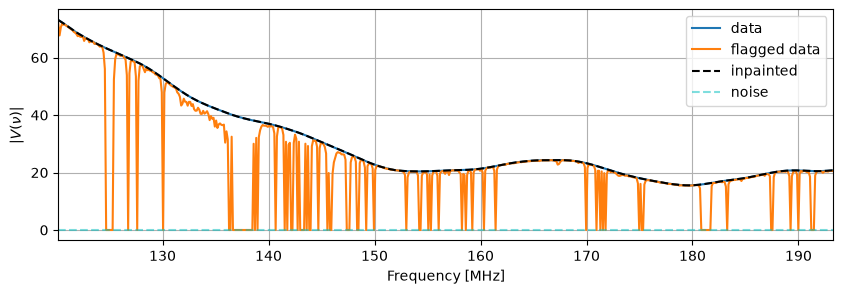

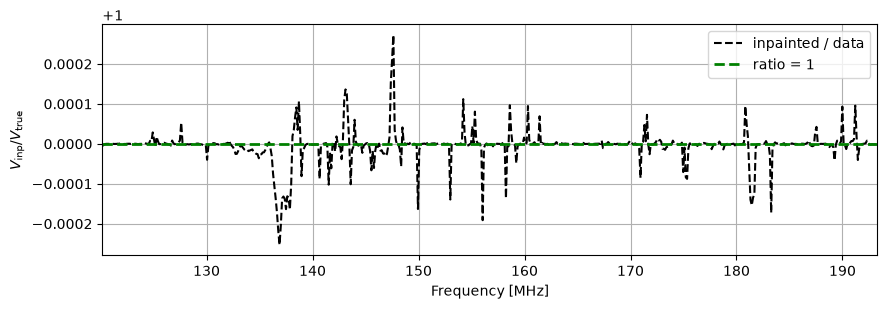

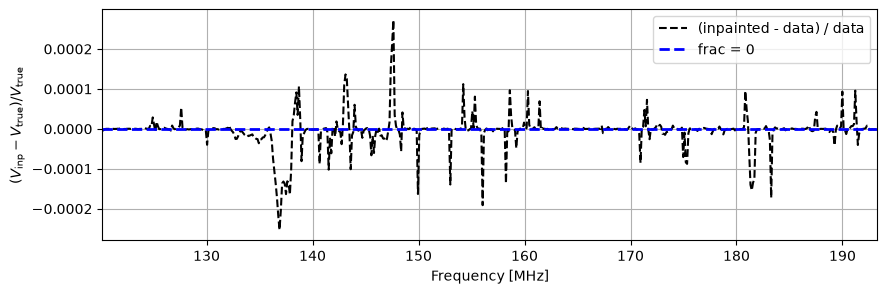

In [211]:
# ==================================================
# Frequency-space comparison: data, flagged, inpainted, noise
# ==================================================

# Compute frequency-space amplitudes once
data_freq = vd_avg.data[0, 0].mean(0).abs().mean(0)
flg_freq  = vd_flg_avg.data[0, 0].mean(0).abs().mean(0)
inp_freq  = vd_inp_avg.data[0, 0].mean(0).abs().mean(0)
ns_freq   = vd_ns_avg.data[0, 0].mean(0).abs().mean(0)

freq = freqs

# Derived quantities
ratio = inp_freq / data_freq
frac_resid = (inp_freq - data_freq) / data_freq


# ==================================================
# 1. Frequency-space amplitude
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(freq, data_freq, label="data")
plt.plot(freq, flg_freq, label="flagged data")
plt.plot(freq, inp_freq, c="k", ls="--", label="inpainted")
plt.plot(freq, ns_freq, c="c", ls="--", alpha=0.5, label="noise")

#plt.yscale("log")
plt.grid()
plt.xlim(freq[0], freq[-1])
# plt.ylim(1e-4, 1e4)

plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel(r"$|V(\nu)|$")


# ==================================================
# 2. Ratio: inpainted / data
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(
    freq,
    ratio,
    c="k",
    ls="--",
    label="inpainted / data",
)

plt.axhline(
    y=1.0,
    color="g",
    linestyle="--",
    linewidth=2,
    label="ratio = 1",
)

plt.grid()
plt.xlim(freq[0], freq[-1])

plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel(r"$V_{\rm inp}/V_{\rm true}$")


# ==================================================
# 3. Fractional residual: (inpainted - data) / data
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(
    freq,
    frac_resid,
    c="k",
    ls="--",
    label="(inpainted - data) / data",
)

plt.axhline(
    y=0.0,
    color="b",
    linestyle="--",
    linewidth=2,
    label="frac = 0",
)

plt.grid()
plt.xlim(freq[0], freq[-1])

plt.legend()
plt.xlabel("Frequency [MHz]")
#plt.ylabel("Fractional residual")
plt.ylabel(r"$(V_{\rm inp} - V_{\rm true}) / V_{\rm true}$")

# 4.2 delay-space averaged |V|: 
## a) |V_inp|, 
## b) V_inp / V_true
## c)(V_inp - V_true) / V_true

Text(0, 0.5, 'Fractional residual')

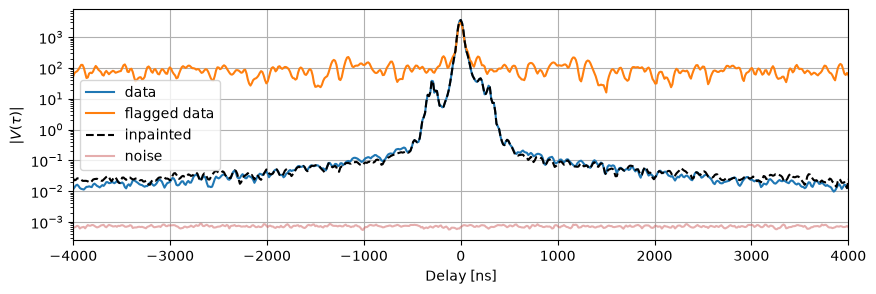

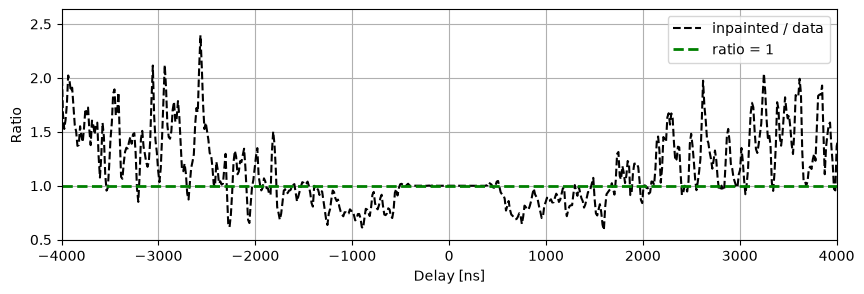

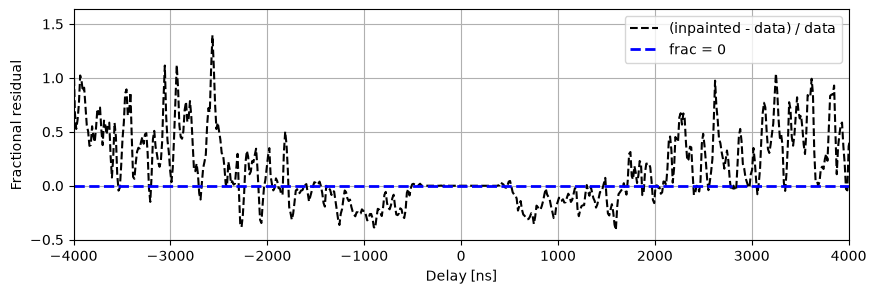

In [213]:
# ==================================================
# Delay-space comparison: data, flagged, inpainted, noise
# ==================================================

# Compute delay spectra once
data_delay = FT1(vd_avg.data[0, 0].mean(0))[:].abs().mean(0)
flg_delay  = FT1(vd_flg_avg.data[0, 0].mean(0))[:].abs().mean(0)
inp_delay  = FT1(vd_inp_avg.data[0, 0].mean(0))[:].abs().mean(0)
ns_delay   = FT1(vd_ns_avg.data[0, 0].mean(0))[:].abs().mean(0)

delay = FT1.freqs

# Derived quantities
ratio = inp_delay / data_delay
frac_resid = (inp_delay - data_delay) / data_delay


# ==================================================
# 1. Delay spectrum
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(delay, data_delay, label="data")
plt.plot(delay, flg_delay, label="flagged data")
plt.plot(delay, inp_delay, c="k", ls="--", label="inpainted")
plt.plot(delay, ns_delay, c="indianred", ls="-", alpha=0.5, label="noise")

plt.yscale("log")
plt.grid()
plt.xlim(-4000, 4000)
# plt.ylim(1e-4, 1e4)

plt.legend()
plt.xlabel("Delay [ns]")
plt.ylabel(r"$|V(\tau)|$")


# ==================================================
# 2. Ratio: inpainted / data
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(
    delay,
    ratio,
    c="k",
    ls="--",
    label="inpainted / data",
)

plt.axhline(
    y=1.0,
    color="g",
    linestyle="--",
    linewidth=2,
    label="ratio = 1",
)

plt.grid()
plt.xlim(-4000, 4000)

plt.legend()
plt.xlabel("Delay [ns]")
plt.ylabel("Ratio")


# ==================================================
# 3. Fractional residual: (inpainted - data) / data
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(
    delay,
    frac_resid,
    c="k",
    ls="--",
    label="(inpainted - data) / data",
)

plt.axhline(
    y=0.0,
    color="b",
    linestyle="--",
    linewidth=2,
    label="frac = 0",
)

plt.grid()
plt.xlim(-4000, 4000)

plt.legend()
plt.xlabel("Delay [ns]")
plt.ylabel("Fractional residual")

# 5. delay-space power spectrum (averaged) : 
## comparison: data, flagged, inpainted, noise

In [223]:
# form power spectrum
ns_pspec = FT1(vd_ns.data[0,0].mean(0)).abs().pow(2)  #[1, 1, 1, 1000, 600][1,1,baseline,time,tau]

vd_pspec0=FT1(vd.data[0,0].mean(0)).abs().pow(2) 
flg_pspec0=FT1(vd_flg.data[0,0].mean(0)).abs().pow(2)
inp_pspec0 =FT1(vd_inp.data[0,0].mean(0)).abs().pow(2)

vd_pspec = vd_pspec0 - ns_pspec.mean(-1,keepdim=True) #?? noise 对tau求平均
flg_pspec = flg_pspec0 - ns_pspec.mean(-1,keepdim=True) 
inp_pspec = inp_pspec0 - ns_pspec.mean(-1,keepdim=True)



Text(0, 0.5, '$(P_{\\rm inp} - P_{\\rm true}) / P_{\\rm true}$')

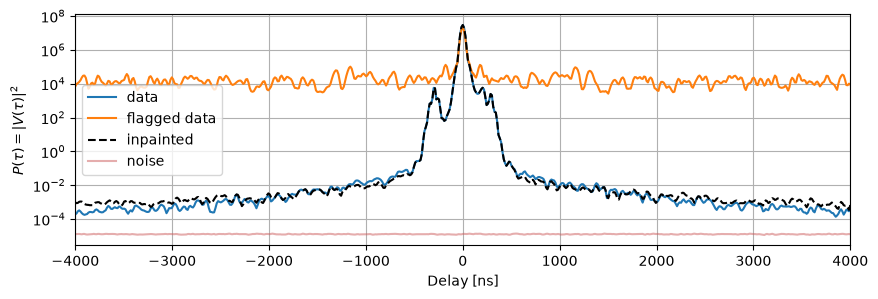

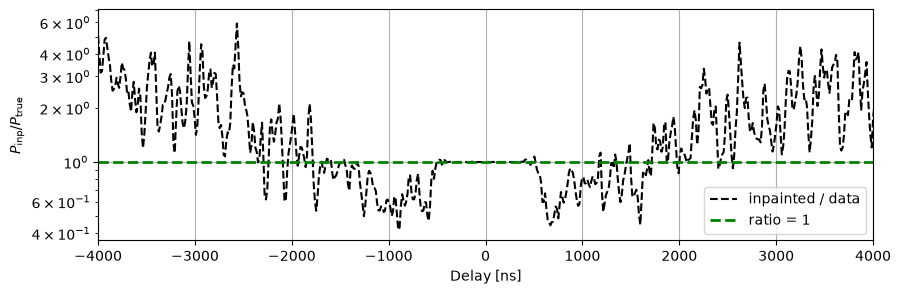

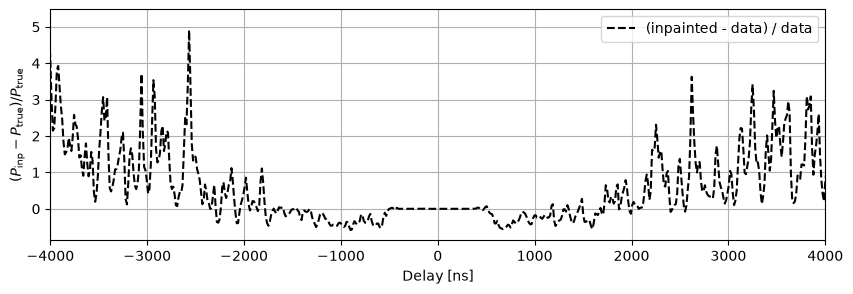

In [239]:
# ==================================================
# Delay-space power-spectrum comparison: data, flagged, inpainted, noise
# ==================================================

# Form power spectra
ns_pspec = FT1(vd_ns.data[0, 0].mean(0)).abs().pow(2)

vd_pspec0  = FT1(vd.data[0, 0].mean(0)).abs().pow(2)
flg_pspec0 = FT1(vd_flg.data[0, 0].mean(0)).abs().pow(2)
inp_pspec0 = FT1(vd_inp.data[0, 0].mean(0)).abs().pow(2)

delay = FT1.freqs

# Average over time / baseline-like remaining dimensions
data_pspec = vd_pspec0.mean(0)
flg_pspec  = flg_pspec0.mean(0)
inp_pspec  = inp_pspec0.mean(0)
noise_pspec = ns_pspec.mean(0)

# Derived quantities
ratio = inp_pspec / data_pspec
frac_resid = (inp_pspec - data_pspec) / data_pspec


# ==================================================
# 1. Delay power spectrum
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(delay, data_pspec, label="data")
plt.plot(delay, flg_pspec, label="flagged data")
plt.plot(delay, inp_pspec, c="k", ls="--", label="inpainted")
plt.plot(delay, noise_pspec, c="indianred", ls="-", alpha=0.5, label="noise")

plt.yscale("log")
plt.grid()
plt.xlim(-4000, 4000)
# plt.ylim(1e-4, 1e8)

plt.yscale('log')
plt.legend()
plt.xlabel("Delay [ns]")
plt.ylabel(r"$P(\tau) = |V(\tau)|^2$")


# ==================================================
# 2. Ratio: inpainted / data
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(
    delay,
    ratio,
    c="k",
    ls="--",
    label="inpainted / data",
)

plt.axhline(
    y=1.0,
    color="g",
    linestyle="--",
    linewidth=2,
    label="ratio = 1",
)

plt.grid()
plt.xlim(-4000, 4000)
plt.yscale('log')
plt.legend()
plt.xlabel("Delay [ns]")
plt.ylabel(r"$P_{\rm inp} / P_{\rm true}$")


# ==================================================
# 3. Fractional residual: (inpainted - data) / data
# ==================================================

plt.figure(figsize=(10, 3))

plt.plot(
    delay,
    frac_resid,
    c="k",
    ls="--",
    label="(inpainted - data) / data",
)



plt.grid()
plt.xlim(-4000, 4000)
#plt.yscale('log')
plt.legend()
plt.xlabel("Delay [ns]")
plt.ylabel(r"$(P_{\rm inp} - P_{\rm true}) / P_{\rm true}$")

# 4. Residual distributions of individual delay-space power spectra

## a) P(tau) residual for small tau

## b) Fractional P(tau) residual for small tau

## c) P(tau) residual for large tau

## d) Fractional P(tau) residual for large tau

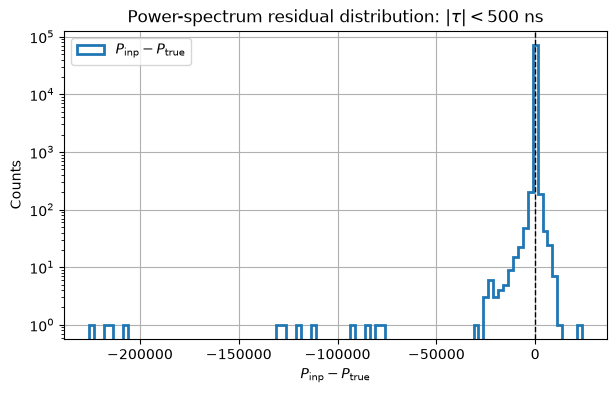

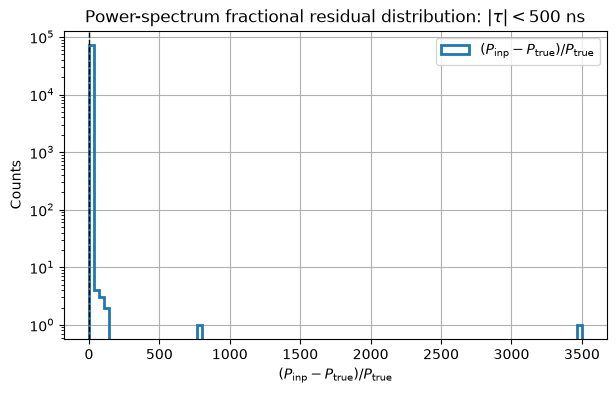

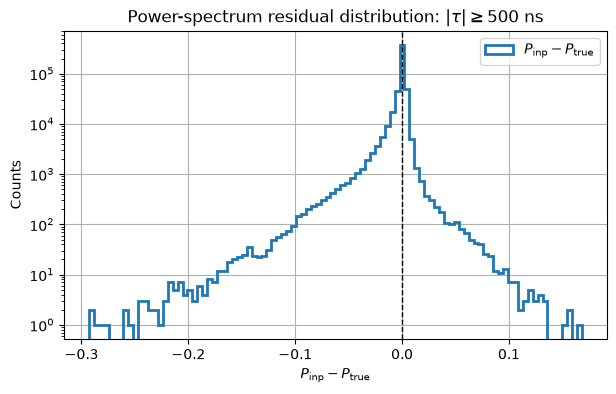

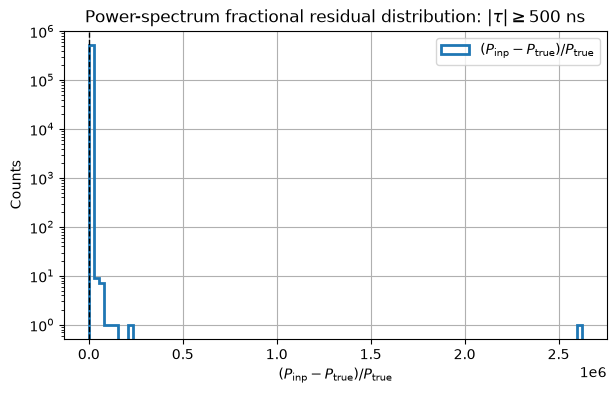

In [316]:
# Delay masks, length = 600

lim_range=500
low_delay_mask = np.abs(delay) < lim_range
high_delay_mask = np.abs(delay) >= lim_range

# Split power spectra by delay range
vd_pspec_low   = vd_pspec0[:, low_delay_mask]
inp_pspec_low  = inp_pspec0[:, low_delay_mask]

vd_pspec_high  = vd_pspec0[:, high_delay_mask]
inp_pspec_high = inp_pspec0[:, high_delay_mask]


# ==================================================
# Helper function: residual distribution plot
# ==================================================

def plot_residual_distributions(inp_pspec, true_pspec, title_suffix):
    # Absolute residual: P_inp - P_true
    abs_resid = inp_pspec - true_pspec

    # Fractional residual: (P_inp - P_true) / P_true
    frac_resid = (inp_pspec - true_pspec) / true_pspec

    # Flatten and remove NaN / inf values
    abs_resid_1d = abs_resid.flatten()
    frac_resid_1d = frac_resid.flatten()

    abs_resid_1d = abs_resid_1d[torch.isfinite(abs_resid_1d)]
    frac_resid_1d = frac_resid_1d[torch.isfinite(frac_resid_1d)]

    # Convert to numpy
    abs_resid_1d = abs_resid_1d.detach().cpu().numpy()
    frac_resid_1d = frac_resid_1d.detach().cpu().numpy()

    # --------------------------------------------------
    # Absolute residual distribution
    # --------------------------------------------------
    plt.figure(figsize=(7, 4))

    plt.hist(
        abs_resid_1d,
        bins=100,
        histtype="step",
        linewidth=2,
        label=r"$P_{\rm inp} - P_{\rm true}$",
    )

    plt.axvline(
        x=0.0,
        color="k",
        linestyle="--",
        linewidth=1,
    )

    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.xlabel(r"$P_{\rm inp} - P_{\rm true}$")
    plt.ylabel("Counts")
    plt.title(f"Power-spectrum residual distribution: {title_suffix}")

    # --------------------------------------------------
    # Fractional residual distribution
    # --------------------------------------------------
    plt.figure(figsize=(7, 4))

    plt.hist(
        frac_resid_1d,
        bins=100,
        histtype="step",
        linewidth=2,
        label=r"$(P_{\rm inp} - P_{\rm true}) / P_{\rm true}$",
    )

    plt.axvline(
        x=0.0,
        color="k",
        linestyle="--",
        linewidth=1,
    )

    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.xlabel(r"$(P_{\rm inp} - P_{\rm true}) / P_{\rm true}$")
    plt.ylabel("Counts")
    plt.title(f"Power-spectrum fractional residual distribution: {title_suffix}")


# ==================================================
# 4.1 Residual distributions for |delay| < 800 ns
# ==================================================

plot_residual_distributions(
    inp_pspec_low,
    vd_pspec_low,
    rf"$|\tau| < {lim_range}$ ns",
)


# ==================================================
# 4.2 Residual distributions for |delay| >= 800 ns
# ==================================================

plot_residual_distributions(
    inp_pspec_high,
    vd_pspec_high,
    rf"$|\tau| \geq {lim_range}$ ns",
)

plt.show()

